# SOB4ES - Comparador de variables
### CRISP-ML(Q) - Fase 4: ranking de variables candidatas a eliminar

Este notebook lee **todos** los archivos `variables_menos_relevantes_*.csv` que cada notebook de modelado exporta (uno por modelo, con sus 10 variables menos relevantes), los cruza, y genera un **ranking general de candidatas a eliminar** del conjunto de features: las variables que se repiten como "poco relevantes" en mas modelos, con metodos de importancia distintos (SHAP, permutacion, coeficientes, gain), son la señal mas solida.

## Formatos de archivo que reconoce

Cada notebook de modelado exporta su propio `variables_menos_relevantes_{modelo}.csv` con alguno de estos formatos, y el notebook detecta automaticamente cual es:

1. **Formato estandar** — columna `variable` + una o mas columnas numericas de importancia, ya ordenado de menor a mayor importancia (la primera fila es la variable menos relevante). Es el que usan RF, XGBoost, RF/XGB Multisalida, RegressorChain y los MLP.
2. **Formato Ridge** — columna `GLOBAL_MENOS_RELEVANTES` con el bottom-10 global ya calculado (mas columnas por target, que aqui no se usan).
3. **Formato roto** — solo una columna de valores numericos, sin nombres de variable (p. ej. si se exporto con `to_csv(index=False)` sobre una Series sin resetear el indice). Estos archivos **no se pueden usar** — se detectan y se listan aparte, sin bloquear el resto del analisis.

## Como identifica el modelo cada archivo

El nombre de cada modelo se deriva del propio nombre de archivo (todo lo que va despues de `variables_menos_relevantes_` o `variables_menos_revelantes_`, por si hay alguna errata). Si aparecen nombres de archivo ambiguos o no reconocidos, se muestran tal cual aparecen para que se puedan revisar a mano.


In [1]:
import os
import glob
import re
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Directorio donde estan los variables_menos_relevantes_*.csv de cada notebook.
# Por defecto, el mismo directorio que este notebook.
DATA_DIR = './output/var/'

PALETTE = {
    'blue': '#7FA6C9', 'blue_light': '#AAD0F1', 'green': '#7FC8A9', 'green_light': '#BEE6D3',
    'purple': '#A98FC7', 'purple_light': '#D6C7EA', 'gray': '#9B9B9B', 'gray_dark': '#5C5C5C',
    'red': '#D98686',
}
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Nombres "bonitos" para los sufijos de archivo mas habituales (ajustar si cambian
# las convenciones de nombres en el proyecto). Si un archivo no aparece aqui, se usa
# su nombre de archivo tal cual, para que sea facil detectarlo y revisarlo a mano.
NOMBRES_MODELO = {
    'rf':                'Random Forest',
    'rf_multisalida':    'RF Multisalida',
    'xgboost':           'XGBoost',
    'xgb':               'XGB Multisalida',
    'ridge':             'Ridge',
    # 'cadena_shap':       'RegressorChain',
    'cadena':            'RegressorChain',
    'mlp_multisalida':   'MLP Multisalida',
    'mlp_custom':        'MLP Perdida Personalizada',
    # 'mlp_permutation':   'MLP (variante sin confirmar - revisar origen)',
}

print('Librerias y configuracion cargadas correctamente...')


Librerias y configuracion cargadas correctamente...


## 1.- Descubrimiento y carga de archivos

Se buscan todos los `variables_menos_relevantes_*.csv` (y la variante con la errata `variables_menos_revelantes_*.csv`) en `DATA_DIR`, se detecta el formato de cada uno, y se extrae su bottom-10 (lista de variables menos relevantes, ordenada de la mas a la menos "poco relevante" dentro de ese top-10).


In [2]:
def nombre_modelo_desde_archivo(path):
    base = os.path.basename(path)
    base = re.sub(r'\.csv$', '', base, flags=re.IGNORECASE)
    base = re.sub(r'^variables_menos_(relevantes|revelantes)_?', '', base, flags=re.IGNORECASE)
    base = re.sub(r'\s*\(\d+\)$', '', base)  # quita sufijos tipo '(1)' de descargas duplicadas
    clave = base.strip().lower()

    # 1. Coincidencia exacta con el diccionario de nombres conocidos
    if clave in NOMBRES_MODELO:
        return NOMBRES_MODELO[clave]

    # 2. Heuristica por palabras clave, para no depender de que el nombre de
    #    archivo sea exactamente igual al esperado (mayusculas, guiones, etc.)
    contiene = lambda *palabras: all(p in clave for p in palabras)
    if contiene('mlp') and contiene('custom'):
        return 'MLP Perdida Personalizada'
    # if contiene('mlp') and contiene('permutation'):
       # return 'MLP (variante sin confirmar - revisar origen)'
    if contiene('mlp') and ('multi' in clave or 'salida' in clave):
        return 'MLP Multisalida'
    if contiene('rf') and ('multi' in clave or 'salida' in clave):
        return 'RF Multisalida'
    if clave in ('rf', 'random_forest', 'randomforest'):
        return 'Random Forest'
    if contiene('xgb') and ('multi' in clave or 'salida' in clave):
        return 'XGB Multisalida'
    if clave in ('xgboost', 'xgb'):
        return 'XGBoost' if clave == 'xgboost' else 'XGB Multisalida'
    if 'ridge' in clave:
        return 'Ridge'
    if 'cadena' in clave or 'chain' in clave:
        return 'RegressorChain'
    else:
        pass
    # 3. Si nada coincide, se devuelve el nombre limpio tal cual (para poder
    #    identificarlo a simple vista y, si hace falta, anadirlo al diccionario)
    return base if base else 'desconocido'


def cargar_bottom10(path):
    """Devuelve (lista_bottom10, motivo_error). Si motivo_error no es None,
    el archivo no se pudo usar y lista_bottom10 sera None."""
    try:
        df = pd.read_csv(path)
    except Exception as e:
        return None, f'no se pudo leer el archivo ({e})'

    columnas = list(df.columns)

    # Formato Ridge: columna GLOBAL_MENOS_RELEVANTES ya calculada
    if 'GLOBAL_MENOS_RELEVANTES' in columnas:
        return df['GLOBAL_MENOS_RELEVANTES'].dropna().tolist(), None

    # Formato estandar: columna 'variable' (+ una o mas columnas numericas)
    if 'variable' in columnas:
        return df['variable'].dropna().tolist(), None

    # Formato roto: ninguna columna de texto reconocible -> no se puede usar
    return None, ('no tiene columna de nombres de variable reconocible '
                   f'(columnas encontradas: {columnas}) - hace falta re-exportar '
                   'conservando el nombre de la variable')


patrones = sorted(
    glob.glob(os.path.join(DATA_DIR, 'variables_menos_relevantes_*.csv')) +
    glob.glob(os.path.join(DATA_DIR, 'variables_menos_revelantes_*.csv'))
)

bottom10_por_modelo = {}
archivos_no_usables = {}

for path in patrones:
    modelo = nombre_modelo_desde_archivo(path)
    bottom10, error = cargar_bottom10(path)
    if error is None:
        bottom10_por_modelo[modelo] = bottom10
    else:
        archivos_no_usables[os.path.basename(path)] = error

print(f'Archivos encontrados: {len(patrones)}')
print(f'Modelos utilizables: {len(bottom10_por_modelo)}')
for modelo, lst in bottom10_por_modelo.items():
    print(f'  OK   {modelo:45} ({len(lst)} variables)')

if archivos_no_usables:
    print(f'\nArchivos NO utilizables: {len(archivos_no_usables)}')
    for nombre, motivo in archivos_no_usables.items():
        print(f'  --   {nombre}: {motivo}')

if not bottom10_por_modelo:
    print('\nNo se pudo cargar ningun archivo utilizable. Revisa DATA_DIR y los nombres de archivo.')

MODELOS_DISPONIBLES = list(bottom10_por_modelo.keys())

Archivos encontrados: 8
Modelos utilizables: 8
  OK   RegressorChain                                (10 variables)
  OK   MLP Multisalida                               (10 variables)
  OK   Random Forest                                 (10 variables)
  OK   RF Multisalida                                (10 variables)
  OK   Ridge                                         (10 variables)
  OK   XGB Multisalida                               (10 variables)
  OK   XGBoost                                       (10 variables)
  OK   MLP Perdida Personalizada                     (10 variables)


## 2.- Bottom-10 por modelo (tal cual se cargo de cada archivo)


In [3]:
for modelo, lst in bottom10_por_modelo.items():
    print(f'{modelo}')
    print('-' * 60)
    for i, var in enumerate(lst, 1):
        print(f'  {i:2d}. {var}')
    print()


RegressorChain
------------------------------------------------------------
   1. plot_total_n_z
   2. clay_content_z
   3. soil_moisture_z
   4. dem_orientacion_deg_z
   5. total_plant_cover_z
   6. dem_pendiente_deg_z
   7. gee_ndvi_verano_z
   8. plot_total_organic_c_z
   9. zn_z
  10. eu_silt_content_z

MLP Multisalida
------------------------------------------------------------
   1. soil_moisture_z
   2. as_z
   3. pb_z
   4. plot_total_n_z
   5. eu_sand_content_z
   6. eu_organic_carbon_octop_z
   7. zn_z
   8. k_z
   9. plot_total_organic_c_z
  10. eu_water_holding_capacity_z

Random Forest
------------------------------------------------------------
   1. total_plant_cover_z
   2. aggregate_stability_z
   3. dem_pendiente_deg_z
   4. as_z
   5. dem_orientacion_deg_z
   6. bulk_density_z
   7. gee_ndvi_verano_z
   8. eu_water_holding_capacity_z
   9. plot_total_organic_c_z
  10. eu_organic_carbon_octop_z

RF Multisalida
----------------------------------------------------------

## 3.- Ranking general de variables a eliminar

Para cada variable se calcula:
- **frecuencia**: en cuantos modelos aparece dentro de su bottom-10.
- **posicion media**: la posicion media (1 = la variable menos relevante de ese modelo, 10 = la decima menos relevante) en los modelos donde aparece. A igualdad de frecuencia, una posicion media mas baja indica que, cuando aparece, suele ser de las peores de todas (mas prioritaria para eliminar).

El ranking final ordena primero por frecuencia (descendente) y despues por posicion media (ascendente).


In [4]:
if MODELOS_DISPONIBLES:
    registros = []
    for modelo, lst in bottom10_por_modelo.items():
        for posicion, var in enumerate(lst, 1):
            registros.append({'variable': var, 'modelo': modelo, 'posicion': posicion})
    df_registros = pd.DataFrame(registros)

    resumen = df_registros.groupby('variable').agg(
        frecuencia=('modelo', 'nunique'),
        posicion_media=('posicion', 'mean'),
    ).sort_values(['frecuencia', 'posicion_media'], ascending=[False, True])

    resumen['modelos'] = resumen.index.map(
        lambda v: sorted(df_registros.loc[df_registros['variable'] == v, 'modelo'].unique())
    )

    n_modelos = len(MODELOS_DISPONIBLES)
    print('=' * 90)
    print(f'RANKING GENERAL DE VARIABLES A ELIMINAR (sobre {n_modelos} modelos utilizables)')
    print('=' * 90)
    for i, (var, fila) in enumerate(resumen.iterrows(), 1):
        print(f'{i:2d}. {var:32} en {fila.frecuencia}/{n_modelos} modelos '
              f'(posicion media: {fila.posicion_media:.1f}/10)')
        print(f'     -> {fila.modelos}')

    umbral = max(2, (n_modelos + 1) // 2)
    candidatas_fuertes = resumen[resumen['frecuencia'] >= umbral]
    print(f'\nCandidatas fuertes a eliminar (aparecen en {umbral} o mas de {n_modelos} modelos):')
    for var in candidatas_fuertes.index:
        print(f'  - {var}')
else:
    resumen = pd.DataFrame()
    print('Sin modelos disponibles, no se puede calcular el ranking.')


RANKING GENERAL DE VARIABLES A ELIMINAR (sobre 8 modelos utilizables)
 1. plot_total_organic_c_z           en 7/8 modelos (posicion media: 6.4/10)
     -> ['MLP Multisalida', 'MLP Perdida Personalizada', 'RF Multisalida', 'Random Forest', 'RegressorChain', 'Ridge', 'XGBoost']
 2. dem_orientacion_deg_z            en 6/8 modelos (posicion media: 4.2/10)
     -> ['MLP Perdida Personalizada', 'RF Multisalida', 'Random Forest', 'RegressorChain', 'Ridge', 'XGBoost']
 3. eu_water_holding_capacity_z      en 6/8 modelos (posicion media: 6.8/10)
     -> ['MLP Multisalida', 'RF Multisalida', 'Random Forest', 'Ridge', 'XGB Multisalida', 'XGBoost']
 4. as_z                             en 5/8 modelos (posicion media: 3.2/10)
     -> ['MLP Multisalida', 'MLP Perdida Personalizada', 'RF Multisalida', 'Random Forest', 'Ridge']
 5. total_plant_cover_z              en 5/8 modelos (posicion media: 3.8/10)
     -> ['RF Multisalida', 'Random Forest', 'RegressorChain', 'XGB Multisalida', 'XGBoost']
 6. dem_p

## 4.- Visualizacion

### 4.1 Frecuencia: en cuantos modelos aparece cada variable como "poco relevante"


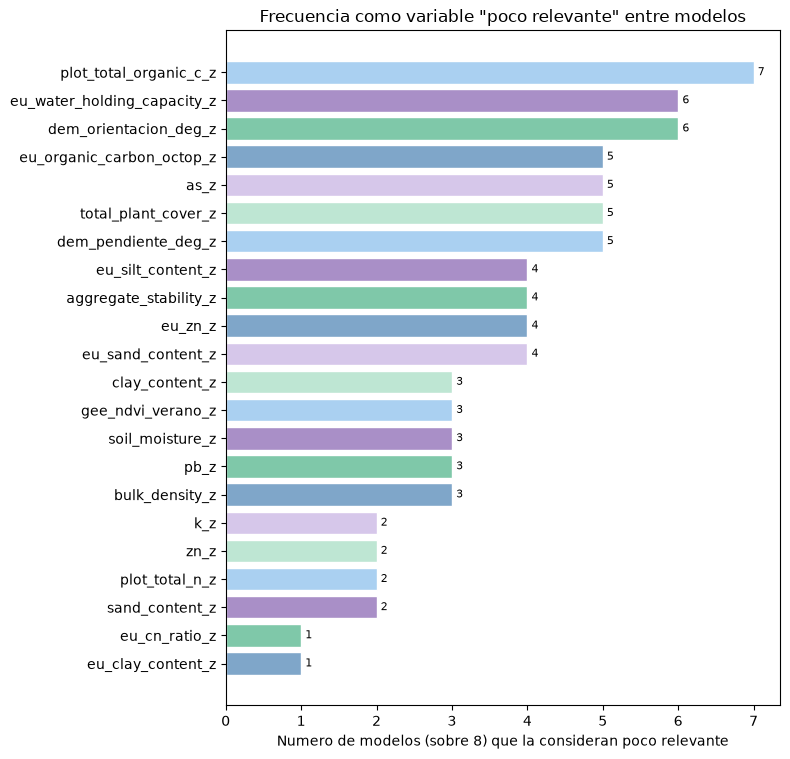

In [5]:
if not resumen.empty:
    frecuencia_ordenada = resumen['frecuencia'].sort_values()

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(frecuencia_ordenada))))
    bars = ax.barh(frecuencia_ordenada.index, frecuencia_ordenada.values,
                    color=palette_cycle(len(frecuencia_ordenada)), edgecolor='white')
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    ax.set_xlabel(f'Numero de modelos (sobre {len(MODELOS_DISPONIBLES)}) que la consideran poco relevante')
    ax.set_title('Frecuencia como variable "poco relevante" entre modelos', fontsize=12)
    plt.tight_layout()
    plt.show()


### 4.2 Mapa de calor: posicion dentro del bottom-10 (variable x modelo)

Cada celda es la posicion de esa variable dentro del bottom-10 de ese modelo (1 = la mas "poco relevante" de todas, 10 = la decima). Las celdas vacias significan que esa variable no aparece en el bottom-10 de ese modelo (no necesariamente que sea muy importante ahi, solo que no esta entre las 10 peores). Ordenado por frecuencia y luego por posicion media.


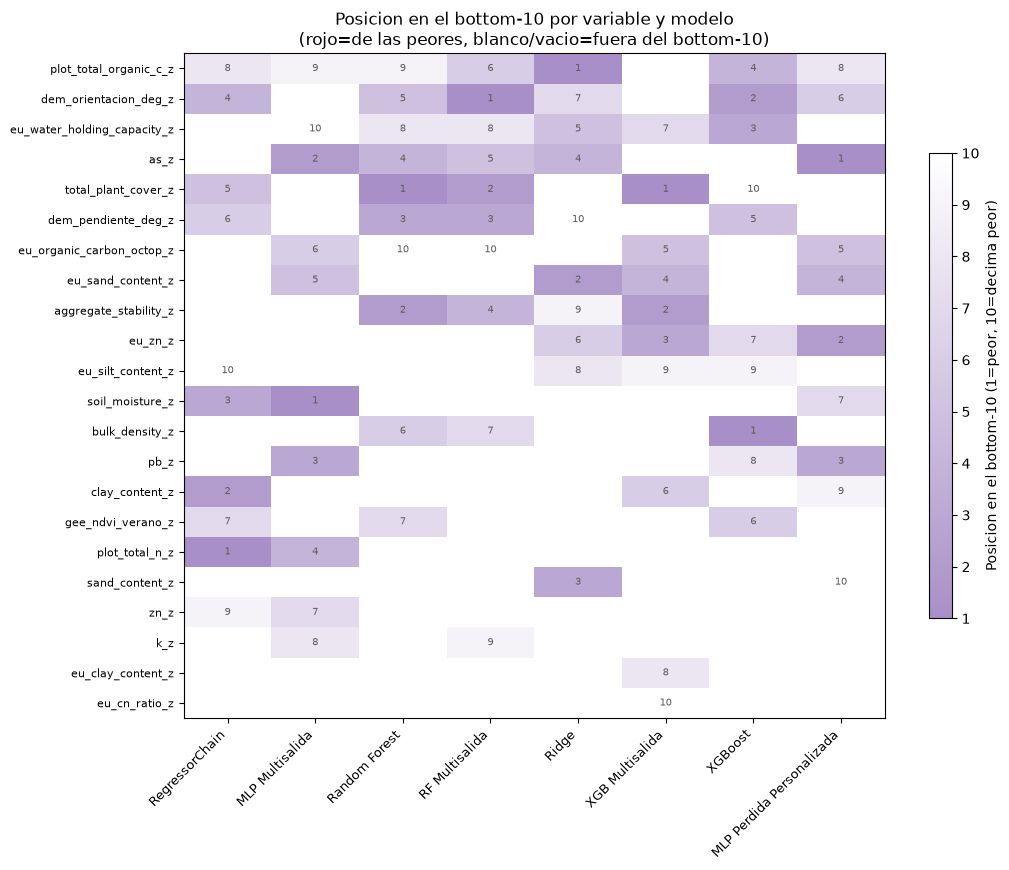

In [6]:
if not resumen.empty:
    orden_filas = resumen.index
    tabla_posiciones = pd.DataFrame(index=orden_filas, columns=MODELOS_DISPONIBLES, dtype=float)
    for modelo, lst in bottom10_por_modelo.items():
        for posicion, var in enumerate(lst, 1):
            if var in tabla_posiciones.index:
                tabla_posiciones.loc[var, modelo] = posicion

    cmap_pos = LinearSegmentedColormap.from_list('sob4es_pos', [PALETTE['purple'], '#FFFFFF'])

    fig, ax = plt.subplots(figsize=(1.1 * len(MODELOS_DISPONIBLES) + 2, max(4, 0.4 * len(orden_filas))))
    data = tabla_posiciones.values.astype(float)
    im = ax.imshow(np.ma.masked_invalid(data), cmap=cmap_pos, vmin=1, vmax=10, aspect='auto')

    ax.set_xticks(range(len(MODELOS_DISPONIBLES)))
    ax.set_xticklabels(MODELOS_DISPONIBLES, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(orden_filas)))
    ax.set_yticklabels(orden_filas, fontsize=8)

    for i in range(len(orden_filas)):
        for j in range(len(MODELOS_DISPONIBLES)):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7, color=PALETTE['gray_dark'])

    fig.colorbar(im, ax=ax, label='Posicion en el bottom-10 (1=peor, 10=decima peor)', shrink=0.7)
    ax.set_title('Posicion en el bottom-10 por variable y modelo\n(rojo=de las peores, blanco/vacio=fuera del bottom-10)', fontsize=12)
    plt.tight_layout()
    plt.show()


## 5.- Archivos que no se pudieron usar

Si alguno de los `variables_menos_relevantes_*.csv` no aparece en las secciones anteriores, es porque no se pudo interpretar correctamente. Aqui se explica el motivo de cada uno para poder corregirlo (normalmente hace falta re-exportar el CSV conservando el nombre de la variable como columna o como indice, en vez de solo los valores numericos).


In [7]:
if archivos_no_usables:
    for nombre, motivo in archivos_no_usables.items():
        print(f'{nombre}:')
        print(f'  {motivo}')
        print()
else:
    print('Todos los archivos encontrados se pudieron usar.')


Todos los archivos encontrados se pudieron usar.


## 6.- Conclusiones y como usar el ranking

- Las variables en "candidatas fuertes a eliminar" (Seccion 3) son las que mas modelos, con metodos de importancia distintos entre si (SHAP, permutacion, coeficientes, gain), coinciden en señalar como poco relevantes. Es la señal mas robusta de todo el analisis.
- **Como probarlo:** quita esas variables de `FEATURES_AUTORIZADAS`, reentrena (tuning + produccion) los modelos afectados, y compara el R2 sobre `eval.csv` con `comparativa_modelos.ipynb` antes y despues. Si el R2 se mantiene o mejora con menos variables, confirma que esas variables solo aportaban ruido/sobreajuste.
- Revisa la Seccion 5 antes de dar el ranking por definitivo: cualquier modelo listado ahi no esta participando en el conteo, y su ausencia puede sesgar el resultado (sobre todo si son modelos con metodos de importancia distintos a los que sí se cargaron).
- Ante cualquier variable que aparezca en pocos modelos pero con posicion medio muy baja (p. ej. 1-2), vale la pena revisarla igualmente: puede que solo la calculen 1-2 modelos con ese metodo en concreto, pero que dentro de esos sea consistentemente la peor de todas.
- Como siempre, la relevancia estadistica es un criterio mas, no el unico: si una variable tiene sentido de dominio (ecologico/edafologico) fuerte, vale la pena mantenerla en el modelo aunque su importancia estadistica sea baja, sobre todo si el coste de mantenerla es bajo.
